# Matching and comparison of the database with external sources

In [2]:
%load_ext autoreload
%autoreload 2

In [15]:
import pandas as pd
import ast
import geopandas as gpd
from copy import deepcopy as dc
from matplotlib.ticker import LogLocator, FuncFormatter

from src.LLM_functions import *
from src.plot_functions import *
from src.data import *
from src.post_process_functions import *
from src.hazard_def import *
from src.external_comparaison import *

#sys.path.append('/home/lhasbini/como_school/como_project4/src/')

In [4]:
# Import extracted impact
res_name = "post_processed_llm_response_impact_labelled_reports_test_multiprompt_continue_16rep_meta-llama_llama-4-scout-17b-16e-instruct"
df_llm = pd.read_csv(DATA_PATH + 'results_proc/'+res_name+'.csv', encoding='utf-8')
df_llm_geo = gpd.read_file(DATA_PATH + 'results_proc/'+res_name+'_geo.gpkg')

#Manually labelled 
df_labelled_geo = gpd.read_file(DATA_PATH + 'results_proc/'+'post_processed_labelled_reports_impacts_all_geo.gpkg')

#Conver columns to list 
col_to_list = ['country', 'location', 'hazards', 'hazards_reclass', 'locationOsm', 'locationGaul']
for col in col_to_list : 
        # df_llm[col] = df_llm[col].apply(
        #     lambda x: ast.literal_eval(x) if pd.notna(x) and isinstance(x, str) and x.strip().startswith("[") else ([x] if pd.notna(x) else None)
        # )

        df_llm_geo[col] = df_llm_geo[col].apply(
            lambda x: ast.literal_eval(x) if pd.notna(x) and isinstance(x, str) and x.strip().startswith("[") else ([x] if pd.notna(x) else None)
        )
        df_labelled_geo[col] = df_labelled_geo[col].apply(
            lambda x: ast.literal_eval(x) if pd.notna(x) and isinstance(x, str) and x.strip().startswith("[") else ([x] if pd.notna(x) else None)
        )

col_to_list = ['country', 'location', 'hazards', 'hazards_reclass']
for col in col_to_list : 
    df_llm[col] = df_llm[col].apply(
        lambda x: ast.literal_eval(x) if pd.notna(x) and isinstance(x, str) and x.strip().startswith("[") else ([x] if pd.notna(x) else None)
    )

In [5]:
df_llm_geo_grp = clean_group(df_llm_geo)
df_labelled_geo_grp = clean_group(df_labelled_geo)

In [6]:
# Import all reports 
file_path = DATA_IN_JSONS + 'all_ifrc_reports_info_processed_extended_v2.json'#'all_ifrc_reports_info_processed_extended.json' #'all_ifrc_reports_info_processed_extended_format_nb_std_units.json'

# Open and read the JSON file
with open(file_path, 'r') as json_file:
    df_all_reports = json.load(json_file)
df_all_reports = pd.DataFrame(df_all_reports)
df_all_reports['date'] = pd.to_datetime(df_all_reports["date"], format="%d/%m/%Y")
df_all_reports = df_all_reports.rename({"date" : "reportDate", "hazards_found_kw" : "hazards"}, axis=1)
df_all_reports['startYear'] = df_all_reports.apply(consolidate_startYear, axis=1)

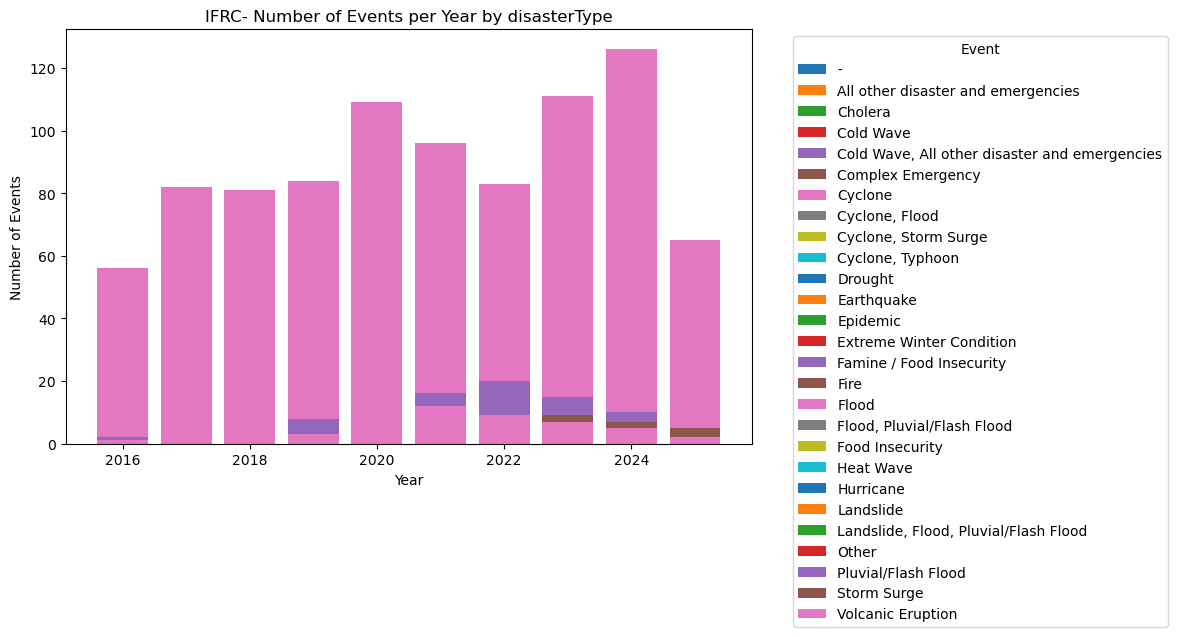

In [147]:
counts = df_all_reports.groupby(["startYear", "disasterType"]).size().reset_index(name="Count")

# 5. Plot
plt.figure(figsize=(12,6))
for event_type, group in counts.groupby("disasterType"):
    plt.bar(group["startYear"], group["Count"], label=event_type)

plt.xlabel("Year")
plt.ylabel("Number of Events")
plt.title("IFRC- Number of Events per Year by disasterType")
plt.legend(title="Event", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [5]:
# Import data from other sources 
df_ifrc_go = open_clean_ifrc_go()
df_ifrc_monty = open_clean_ifrc_monty(df_ifrc_go)

In [20]:
from matplotlib.ticker import ScalarFormatter
def plot_affected_people(df_llm_geo_grp, df_labelled_geo_grp, df_impact_ifrc_monty_appeal, df_go_subset, appealCodelist, impactType):
    # --- Prepare each source ---
    df1 = (
        df_llm_geo_grp[(df_llm_geo_grp["impactSubtype"] == impactType) & 
                       (df_llm_geo_grp["appealCode"].isin(appealCodelist))]
        [["appealCode", "impactValue_final"]]
        .groupby("appealCode", as_index=False)
        .sum()
        .rename(columns={"impactValue_final": "LLM_extracted"})
    )

    df2 = (
        df_labelled_geo_grp[(df_labelled_geo_grp["impactSubtype"] == impactType) & 
                       (df_labelled_geo_grp["appealCode"].isin(appealCodelist))]
        [["appealCode", "impactValue_final"]]
        .groupby("appealCode", as_index=False)
        .sum()
        .rename(columns={"impactValue_final": "Manual_labelling"})
    )

    df3 = (
        df_impact_ifrc_monty_appeal[(df_impact_ifrc_monty_appeal["impact_type"] == impactType)& 
                                    (df_impact_ifrc_monty_appeal["appealCode"].isin(appealCodelist))]
        [["appealCode", "impact_value"]]
        .groupby("appealCode", as_index=False)
        .sum()
        .rename(columns={"impact_value": "IFRC_Monty"})
    )

    df4 = df_go_subset[["appealCode", impactType]].loc[df_go_subset["appealCode"].isin(appealCodelist)].rename(
        columns={impactType : "IFRC_GO"}
    )

    # --- Merge all together ---
    df_all = df1.merge(df2, on="appealCode", how="outer").merge(df3, on="appealCode", how="outer").merge(df4, on="appealCode", how="outer")

    # --- Plot ---
    ax = df_all.set_index("appealCode").plot(
        kind="bar", figsize=(12, 6), width=0.8, logy=True
    )

    # Format y-axis to switch to scientific notation for large values
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((-3, 3))  # auto switch if values <1e-3 or >1e3
    ax.yaxis.set_major_formatter(formatter)
    
    plt.title(f"Number of {impactType} by Appeal Code (Comparison of Sources)")
    plt.xlabel("Appeal Code")
    plt.ylabel("Number of Affected People")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    return df_all


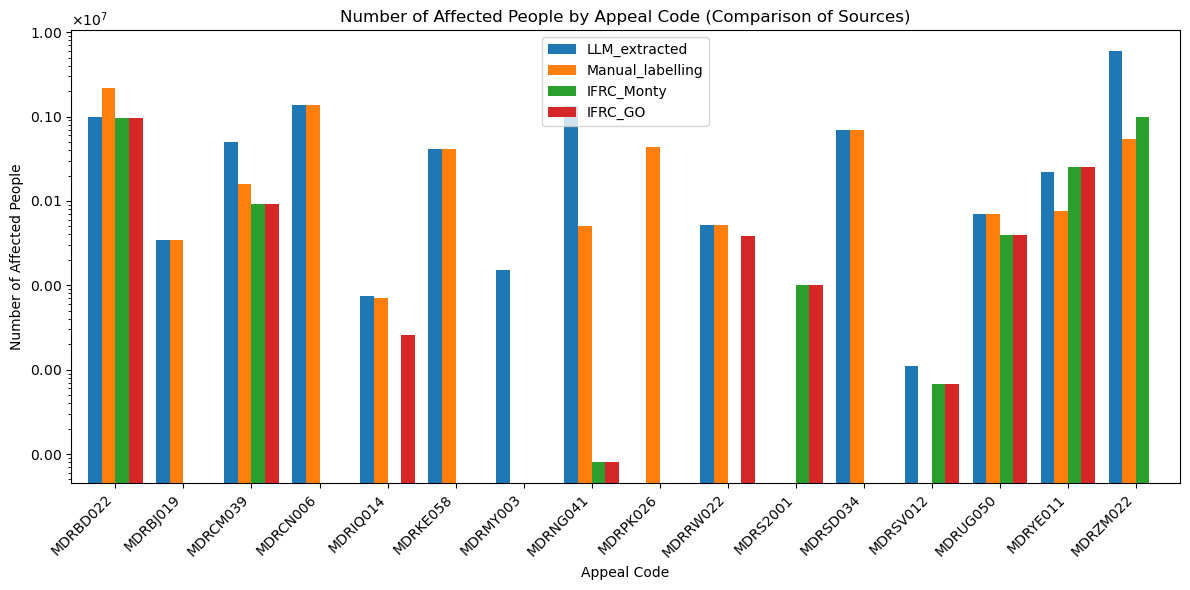

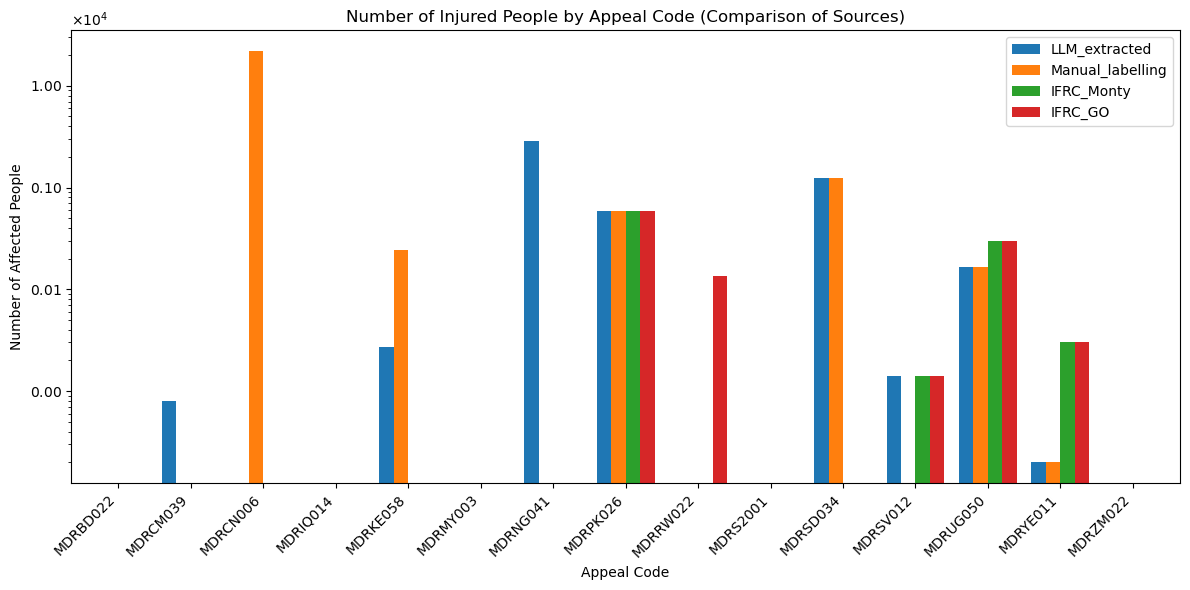

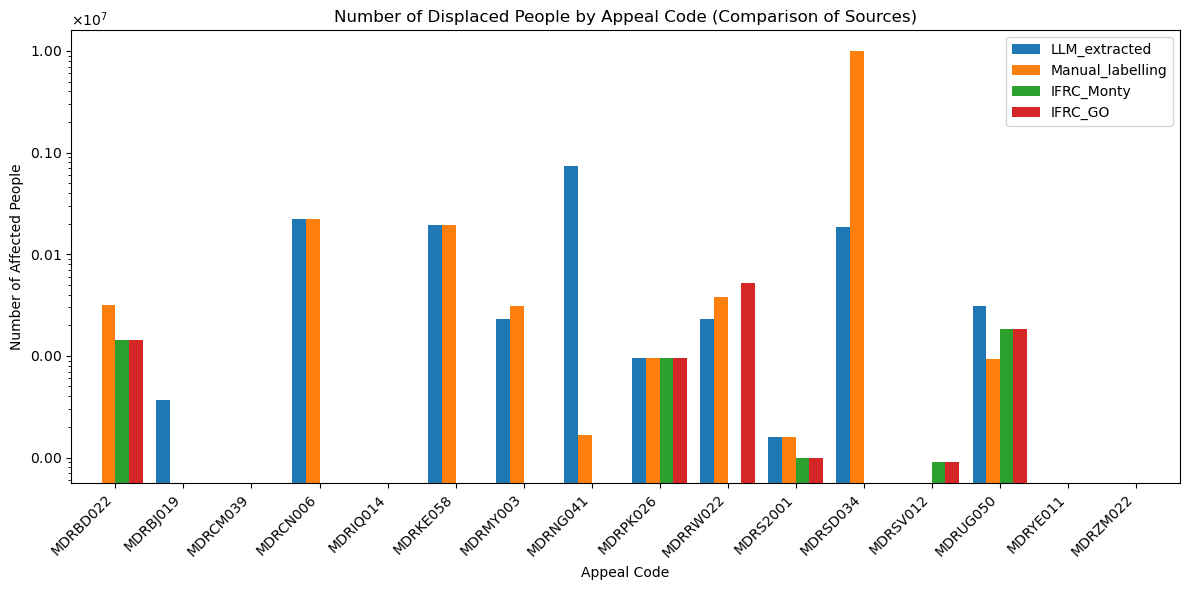

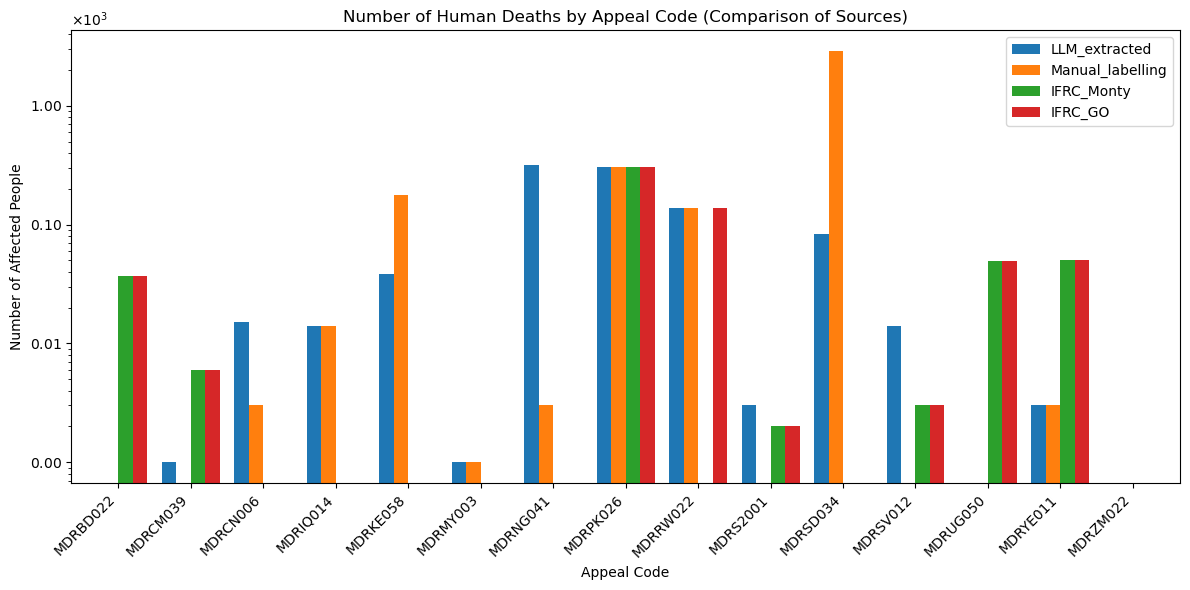

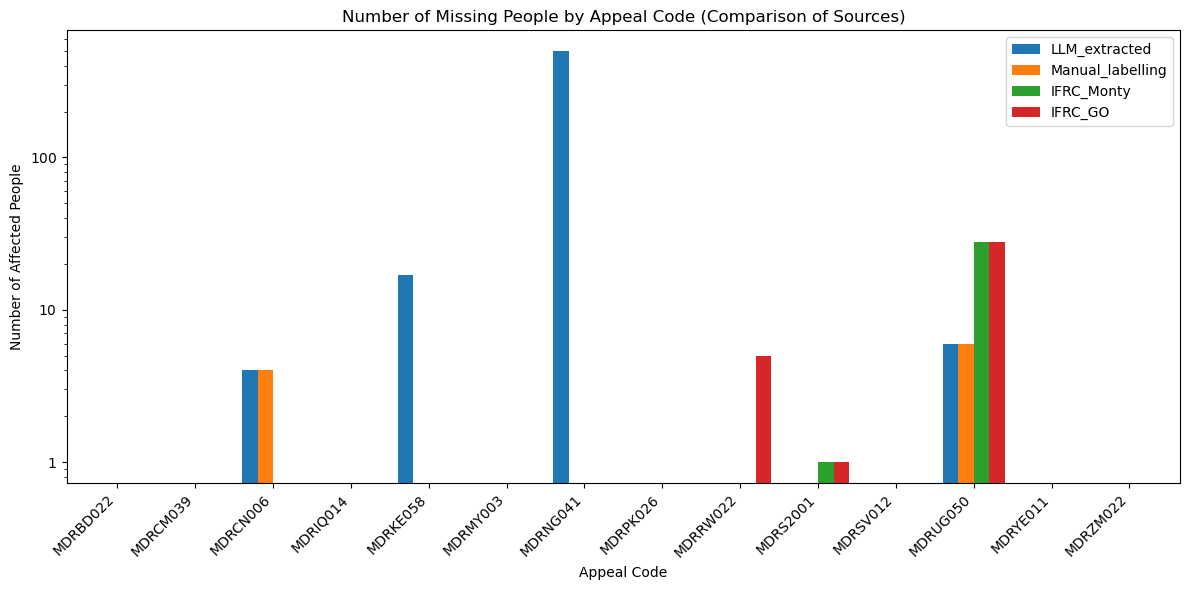

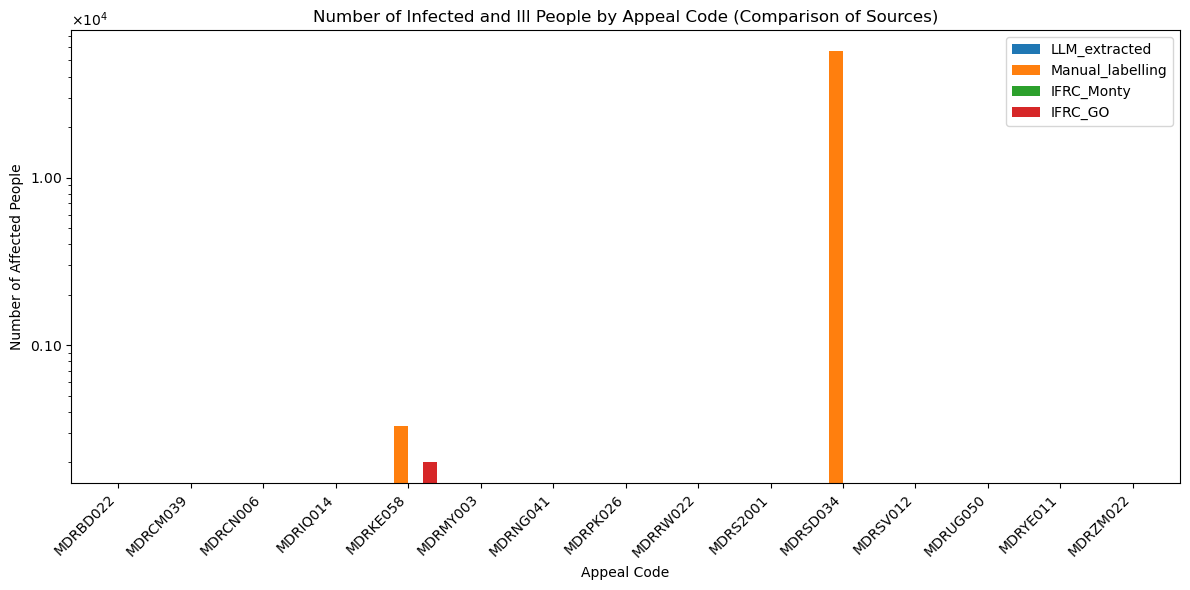

In [33]:
impact_list = list(mapping_impact_type.keys())
for impactType in  impact_list: 
    df_plot_data = plot_affected_people(df_llm_geo_grp, df_labelled_geo_grp, df_ifrc_monty, df_ifrc_go, df_llm_geo_grp.appealCode.unique(), impactType)

In [37]:
from pystac_client import Client
#get catalog
monty_api = "https://montandon-eoapi-stage.ifrc.org/stac/"
catalog = Client.open(monty_api)#"https://montandon-eoapi-stage.ifrc.org/stac/api")

In [100]:
# def safe_item_collection(search):
#     """Fetch all items from a pystac_client.ItemSearch safely, page by page."""
#     all_items = list(search.items())   # stream + collect into list
#     return ItemCollection(all_items)

from pystac import ItemCollection
def safe_item_collection(search, max_items=None):
    """Fetch items page by page and combine into one ItemCollection.
    If max_items is set, stop after collecting that many.
    """
    all_items = []
    count = 0
    
    for item in search.items():
        all_items.append(item)
        count += 1
        if max_items and count >= max_items:
            break
    return ItemCollection(all_items)


def emdat_to_dataframe_full(search, max_items=None):
    """Fetch all items from a pystac_client.ItemSearch into a DataFrame, including all properties and geometry."""
    rows = []
    count = 0
    
    for item in search.items():
        row = dict(item.properties)  # copy all properties
        row["id"] = item.id          # add item id
        row["geometry"] = item.geometry  # add geometry
        rows.append(row)
        count += 1
        if max_items and count >= max_items:
            break
    
    return pd.DataFrame(rows)

In [ ]:
event_collection_all_emdat_search = catalog.search(collections=["emdat-events"])#.item_collection()
# event_collection_all_emdat = safe_item_collection(event_collection_all_emdat_search, max_items=500)
df_emdat = emdat_to_dataframe_full(event_collection_all_emdat_search, max_items=500)

In [101]:
impact_collection_all_emdat_search = catalog.search(collections=["emdat-events"])#.item_collection()
# impact_collection_all_emdat = safe_item_collection(impact_collection_all_emdat_search, max_items=500)
df_impact_emdat = emdat_to_dataframe_full(impact_collection_all_emdat_search, max_items=500)

In [102]:
df_impact_emdat.to_csv(DATA_EXTERNAL_SOURCE + 'emdat_monty_subset.csv')

In [103]:
df_impact_emdat.head()

,roles,title,datetime,description,end_datetime,monty:etl_id,monty:corr_id,start_datetime,monty:hazard_codes,monty:country_codes,monty:episode_number,id,geometry
0,"[source, event]",Road in India,2025-07-29T00:00:00Z,"Road in Deoghar (Jharkhand state), India of Ju...",2025-07-29T00:00:00Z,5217e777-a13a-4c98-9ab4-7c90c0b6c743,20250729-IND-TEC-TRA-ROA-ROA-1-GCDB,2025-07-29T00:00:00Z,[tec-tra-roa-roa],[IND],1,emdat-event-2025-0633-IND,"{'type': 'MultiPolygon', 'coordinates': [[[[78..."
1,"[source, event]",Ground movement in Guatemala,2025-07-29T00:00:00Z,Earthquake in Jerez municipality (Jutiapa depa...,2025-07-29T00:00:00Z,d2f134cb-bfae-4133-80f5-a2feedb77155,20250729-GTM-NAT-GEO-EAR-GRO-1-GCDB,2025-07-29T00:00:00Z,[nat-geo-ear-gro],[GTM],1,emdat-event-2025-0621-GTM,"{'type': 'Point', 'coordinates': [-89.883, 14...."
2,"[source, event]",Flood (General) in Romania,2025-07-28T00:00:00Z,"Flood in Suceava, Neamt counties, Romania of J...",2025-07-28T00:00:00Z,eb2d0a9f-807d-47c4-8015-621ef17a4788,20250728-ROU-NAT-HYD-FLO-FLO-1-GCDB,2025-07-28T00:00:00Z,[nat-hyd-flo-flo],[ROU],1,emdat-event-2025-0632-ROU,"{'type': 'Polygon', 'coordinates': [[[28.21484..."
3,"[source, event]",Road in China,2025-07-27T00:00:00Z,"Road in Shanxi, China of July 2025",2025-07-27T00:00:00Z,ee6c3cd1-a4d4-476e-a439-4029f0806155,20250727-CHN-TEC-TRA-ROA-ROA-1-GCDB,2025-07-27T00:00:00Z,[tec-tra-roa-roa],[CHN],1,emdat-event-2025-0630-CHN,"{'type': 'MultiPolygon', 'coordinates': [[[[13..."
4,"[source, event]",Flash flood in Nigeria,2025-07-27T00:00:00Z,"Flood in Yola (Adamawa State), Nigeria of July...",2025-07-27T00:00:00Z,06c90484-caf3-4a33-a2e5-0c3973ac0574,20250727-NGA-NAT-HYD-FLO-FLA-1-GCDB,2025-07-27T00:00:00Z,[nat-hyd-flo-fla],[NGA],1,emdat-event-2025-0626-NGA,"{'type': 'MultiPolygon', 'coordinates': [[[[13..."


# Matching with MONTANDON IFRC and IFRC GO 

In [96]:
# Open csv
df_go_all = pd.read_csv(DATA_EXTERNAL_SOURCE + 'ifrc_go_all.csv')
df_impact_ifrc_monty = pd.read_csv(DATA_EXTERNAL_SOURCE + 'ifrc_monty_all.csv')
df_impact_ifrc_monty["datetime"] = pd.to_datetime(df_impact_ifrc_monty["datetime"], errors="coerce")
df_impact_ifrc_monty["Year"] = df_impact_ifrc_monty["datetime"].dt.year


In [ ]:
df_impact_ifrc_monty['monty:corr_id'].nunique()

397

In [108]:
# Add the appealCode column
df_go_all = df_go_all.rename({"appeals_code" : "appealCode"}, axis=1)
df_go_all["id"] = df_go_all["id"].astype(int)

# Add the appealCode to df_impact_ifrc_monty
df_impact_ifrc_monty_appeal = df_impact_ifrc_monty.copy()
df_impact_ifrc_monty_appeal["id_clean"] = df_impact_ifrc_monty_appeal["id"].str.extract(r"ifrcevent-impact--(\d+)-")
df_impact_ifrc_monty_appeal["id_clean"] = df_impact_ifrc_monty_appeal["id_clean"].astype(int)

## Merge with df_go_subset on this clean id
df_impact_ifrc_monty_appeal = df_impact_ifrc_monty_appeal.merge(
    df_go_all[["id", "appealCode"]].rename(columns={"id": "id_clean"}),
    on="id_clean",
    how="left"
)
df_impact_ifrc_monty_appeal = df_impact_ifrc_monty_appeal.drop(columns=["id_clean"])

In [109]:
df_impact_ifrc_monty_appeal = pd.merge(df_impact_ifrc_monty_appeal, df_all_reports[["appealCode", "hazards"]], on="appealCode")

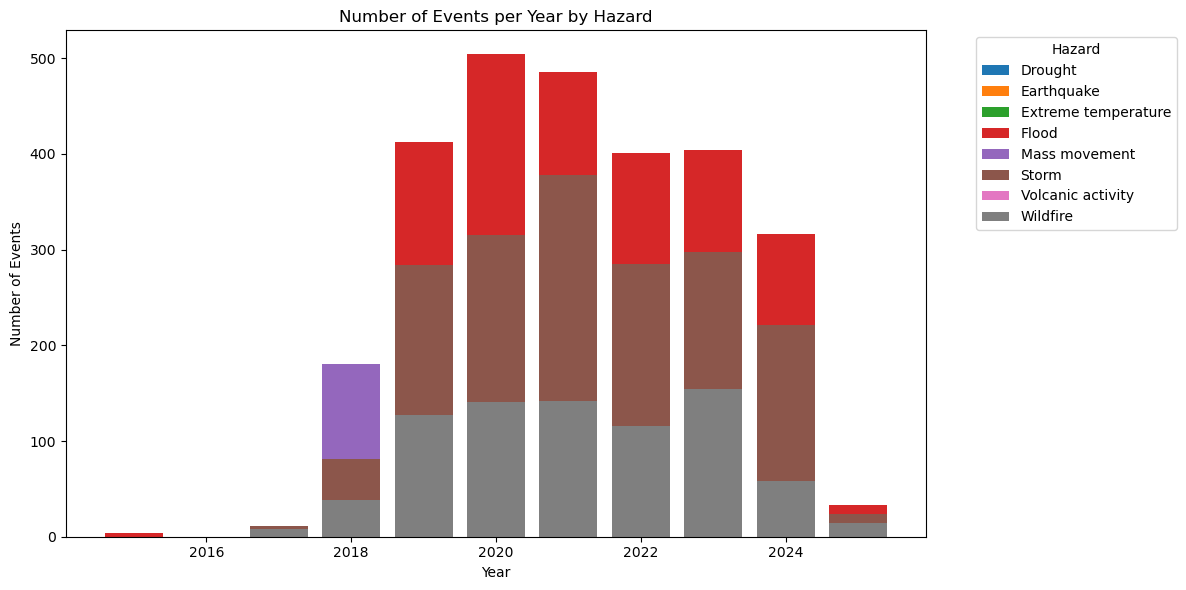

In [110]:
# Explode hazards list so each hazard has its own row
df_expanded = df_impact_ifrc_monty_appeal.explode("hazards")

# Count events per year and hazard
counts = (
    df_expanded.groupby(["Year", "hazards"])
    .size()
    .reset_index(name="Count")
)

# Plot
plt.figure(figsize=(12,6))
for hazard, group in counts.groupby("hazards"):
    plt.bar(group["Year"], group["Count"], label=hazard)

plt.xlabel("Year")
plt.ylabel("Number of Events")
plt.title("Number of Events per Year by Hazard")
plt.legend(title="Hazard", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Matching with Desinventar

In [ ]:
# df_desinventar = pd.read_csv(DATA_EXTERNAL_SOURCE + 'desinventar_monty_subset.csv', encoding='utf-8')

# # Look for common monty:corr_id
# common = df_desinventar.merge(df_ifrc_monty, on='monty:corr_id')
# print("DESINVENTAR, Common Corr_id : ", common['monty:corr_id'].nunique())

C:\Users\lhasbini\AppData\Local\Temp\ipykernel_22744\4163181539.py:2: DtypeWarning: Columns (10,11,12,13,14,15,16,17,18,19,31,32,33,34,35,36,37,38,39,40,41,42,43,50,51,52,54,57,60,61,62,63,64,70,71,72,73,74,77,78,79,82,91,92,101) have mixed types. Specify dtype option on import or set low_memory=False.
  df_desinventar_source = pd.read_csv(


In [ ]:
df_desinventar_source = pd.read_csv(
    DATA_EXTERNAL_SOURCE + 'desinventar_source.csv', 
    encoding='utf-8', 
    sep=';'
)

In [119]:
#### Preprocess the database 
df_desinventar_source = df_desinventar_source.loc[:, ~df_desinventar_source.columns.str.contains("^Unnamed")]
df_desinventar_source["Date"] = pd.to_datetime(df_desinventar_source["Date (YMD)"], errors="coerce", dayfirst=True)
df_desinventar_source["Year"] = df_desinventar_source["Date"].dt.year

#### Convert the hazard to EMDAT main type

# Map hazards to emdat hazards 
reverse_mapping = {}
for main, subs in hazard_mapping_emdat.items():
    for s in subs:
        reverse_mapping[s.lower()] = main   # lowercase for robustness

# --- For df_em_dat (single hazard per row) ---
df_desinventar_source["Event_mapped"] = df_desinventar_source["Event"].str.lower().map(reverse_mapping)
df_desinventar_source_filter = df_desinventar_source.dropna(subset=["Event_mapped"])

print(f"Initially {df_desinventar_source["Serial"].nunique()} events with unique Serial, decrease to {df_desinventar_source_filter["Serial"].nunique()} with cleaning")

Initially 194629 events with unique Serial, decrease to 132735 with cleaning


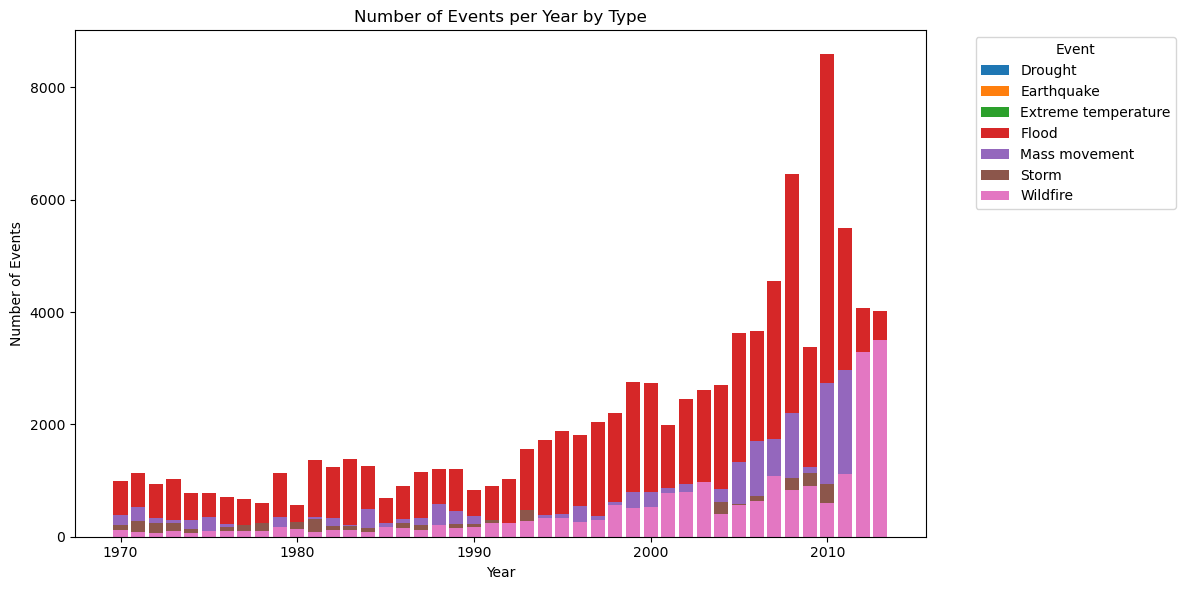

In [122]:
counts = df_desinventar_source.groupby(["Year", "Event_mapped"]).size().reset_index(name="Count")

# 5. Plot
plt.figure(figsize=(12,6))
for event_type, group in counts.groupby("Event_mapped"):
    plt.bar(group["Year"], group["Count"], label=event_type)

plt.xlabel("Year")
plt.ylabel("Number of Events")
plt.title("Number of Events per Year by Type")
plt.legend(title="Event", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [139]:
## Look for unique hazard
## Rename emdat columns 
df_desinventar_match = df_desinventar_source_filter.copy().rename({'&quot;Code Country&quot;' : 'iso_code', "Year" : "startYear"}, axis=1)

# First merge on country + startYear
df_all_reports_desinventar = df_desinventar_match.merge(df_all_reports, on=['iso_code','startYear'], how='inner', suffixes=('_desinv', '_llm'))

# # Keep only rows where Disaster Type is inside hazards list
# df_all_reports_desinventar = df_all_reports_desinventar[
#     df_all_reports_desinventar.apply(lambda row: row["hazards_desinventar"] in row["hazards"], axis=1)
# ].reset_index(drop=True)

# df_llm_desinventar = df_llm_desinventar[
#     df_llm_desinventar.apply(lambda row: row["country_emdat"] in row["country"], axis=1)
# ].reset_index(drop=True)

In [123]:
# # Function to map hazard names to main types
# def map_to_main_type(name):
#     for main_type, names in hazard_mapping_emdat.items():
#         if name in names:
#             return main_type
#     return None  # fallback if not found

# # Process a single row
# def get_hazard(codes_str):
#     codes = [c.strip() for c in codes_str.split(',')]  # split by comma
#     for c in codes:
#         hazard_name = emdat_undrr_to_name.get(c)
#         if hazard_name:
#             main_type = map_to_main_type(hazard_name)
#             if main_type:
#                 return main_type
#     return None

# # Apply to dataframe
# df_desinventar['hazards_desinventar'] = df_desinventar['monty:hazard_codes'].apply(get_hazard)

# # Convert to datetime
# # df_desinventar['start_datetime'] = pd.to_datetime(df_desinventar['start_datetime'], utc=True)
# df_desinventar['startYear'] = df_desinventar['start_datetime'].str[:4].astype(int)

# #Remove the year before 2000 and after 2025
# len_before = len(df_desinventar)
# df_desinventar = df_desinventar.loc[(df_desinventar["startYear"] >=2000) & (df_desinventar["startYear"] <=2025)]
# df_desinventar = df_desinventar[df_desinventar['hazards_desinventar'].notna()]
# len_after = len(df_desinventar)
# print(f"Remove {len_before- len_after} row with incorrect year or hazard")

In [137]:
# # Look for unique hazard
# ## Rename emdat columns 
# df_desinventar_match = df_desinventar.copy().rename({'monty:country_codes' : 'iso_code'}, axis=1)

# # First merge on country + startYear
# df_all_reports_desinventar = df_desinventar_match.merge(df_all_reports, on=['iso_code','startYear'], how='inner', suffixes=('_desinv', '_llm'))

# # Keep only rows where Disaster Type is inside hazards list
# df_all_reports_desinventar = df_all_reports_desinventar[
#     df_all_reports_desinventar.apply(lambda row: row["hazards_desinventar"] in row["hazards"], axis=1)
# ].reset_index(drop=True)

# # df_llm_desinventar = df_llm_desinventar[
# #     df_llm_desinventar.apply(lambda row: row["country_emdat"] in row["country"], axis=1)
# # ].reset_index(drop=True)

In [108]:
print(f"From the {df_all_reports["appealCode"].nunique()} reports, manage to link {df_all_reports_desinventar["appealCode"].nunique()}")

From the 710 reports, manage to link 64


In [122]:
appeal_df_desinventar = df_all_reports_desinventar.appealCode.unique()

In [123]:
appeal_codes = [
    "MDRDZ011","MDRPK026","MDRCM039","MDRBJ019","MDRSD034","MDRNG041","MDRRW022",
    "MDRZM022","MDRUG050","MDRMZ024","MDRAF014","MDRCM036","MDRDZ008","MDRSY006",
    "MDRBR010","MDRID013","MDR55001","MDRLA009","MDRMG020","MDRNI012","MDRBZ006",
    "MDRCN006","MDRBD022","MDRYE011","MDRS2001","MDRIQ014","MDRGN015","MDRSV012",
    "MDRMY003","MDRBD015","MDRKE058","MDRCO023","MDRGW003","MDRHU005","MDRPH021",
    "MDRRS015","MDRMN017","MDRGT009","MDRTR004","MDRIN028","MDRTN010","MDRCR012",
    "MDRGE019"
]

In [124]:
common_codes = list(set(appeal_codes_labelled) & set(appeal_df_desinventar))
print("Common appealCodes:", common_codes)

Common appealCodes: ['MDRKE058', 'MDRGW003', 'MDRZM022']


In [131]:
# Look for extreme temperature 
df_exploded.loc[df_exploded["hazards"]=="Earthquake"].appealCode.unique()

array(['MDRMM009'], dtype=object)

In [129]:
df_exploded["hazards"].unique()

array(['Drought', 'Flood', 'Storm', 'Mass movement', 'Wildfire',
       'Earthquake', 'Volcanic activity'], dtype=object)

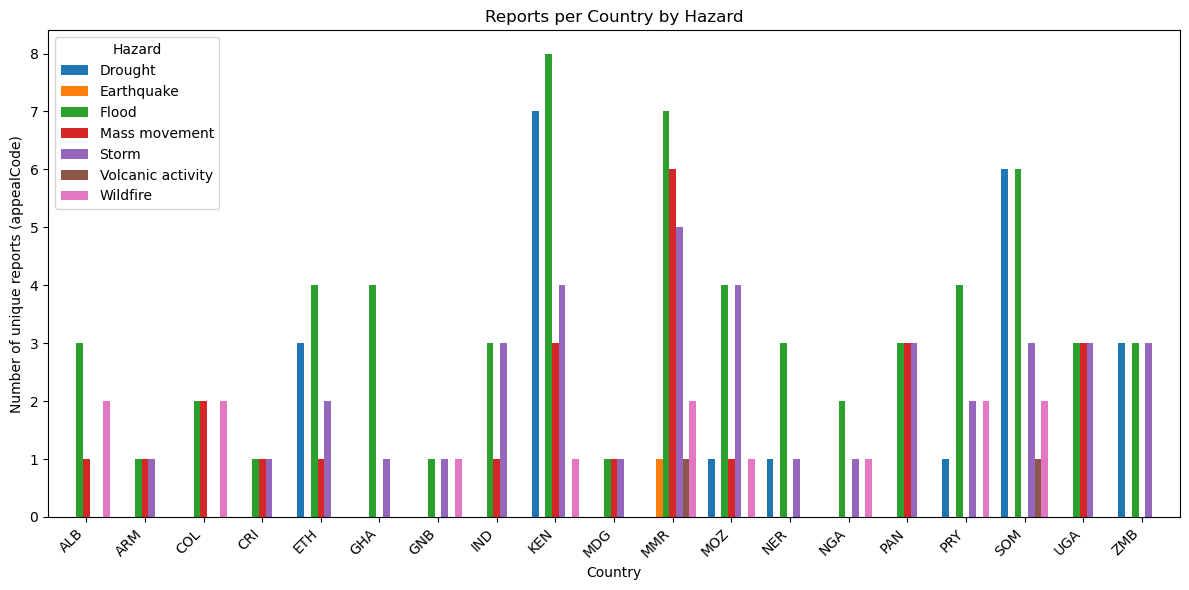

In [116]:
# Step 1: explode hazard list into separate rows
df_exploded = df_all_reports_desinventar.explode("hazards")

# Step 2: count number of reports per country × hazard
df_plot = (
    df_exploded.groupby(["iso_code", "hazards"])["appealCode"]
    .nunique()   # if "Nb of reports" means unique appeals
    .reset_index()
)

# Step 3: pivot for grouped barplot
df_pivot = df_plot.pivot(index="iso_code", columns="hazards", values="appealCode").fillna(0)

# Step 4: plot grouped bars
ax = df_pivot.plot(
    kind="bar",
    figsize=(12, 6),
    width=0.8
)

# Formatting
plt.ylabel("Number of unique reports (appealCode)")
plt.xlabel("Country")
plt.title("Reports per Country by Hazard")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Hazard")
plt.tight_layout()
plt.show()


In [ ]:
# Matching with all available reports
## Rename emdat columns 
df_desinventar_match = df_desinventar.copy().rename({'monty:country_codes' : 'country_iso3_kw'}, axis=1)

# First merge on country + startYear
df_llm_desinventar = df_desinventar_match.merge(df_all_reports, on=['country_iso3_kw','startYear'], how='inner', suffixes=('_desinv', '_llm'))

# Keep only rows where Disaster Type is inside hazards list
df_llm_desinventar = df_llm_desinventar[
    df_llm_desinventar.apply(lambda row: row["hazards_desinventar"] in row["hazards"], axis=1)
].reset_index(drop=True)

# df_llm_desinventar = df_llm_desinventar[
#     df_llm_desinventar.apply(lambda row: row["country_emdat"] in row["country"], axis=1)
# ].reset_index(drop=True)

In [51]:
# Step 1 : Drop the annotated for which the country is not cover in desinventar
desinventar_countries = df_desinventar["monty:country_codes"].unique()
df_llm_geo_grp_filter_ctry = df_llm_geo_grp.loc[df_llm_geo_grp['country_iso3_kw'].isin(desinventar_countries)]

In [53]:
df_llm_geo_grp_filter_ctry.appealCode.unique()

array(['MDRKE058', 'MDRNG041', 'MDRRW022', 'MDRS2001', 'MDRSV012',
       'MDRUG050', 'MDRZM022'], dtype=object)

In [12]:
appeal_disno_counts = (
    df_llm_desinventar
    .groupby("appealCode")["monty:corr_id"]
    .nunique()
    .reset_index(name="unique_corr_id_count")
)

## Case study Kenya 

Use data directly download from the Desinventar table query \
Look whether with such date, matching can be done with the extracted IFRC informations 

In [80]:
df_desinventar_kenya = pd.read_csv(
    DATA_EXTERNAL_SOURCE + 'DI_report73509.xls', 
    sep="\t",        # tab-separated
    encoding="utf-8" # adjust if needed (try 'latin1' if errors)
)
df_desinventar_kenya["country_desinventar"] = "Kenya"
df_desinventar_kenya["iso_code"] = "KEN"
df_desinventar_kenya["Date (YMD)"] = pd.to_datetime(df_desinventar_kenya["Date (YMD)"], errors="coerce")
df_desinventar_kenya = df_desinventar_kenya.dropna(subset=["Date (YMD)"]).reset_index(drop=True)
df_desinventar_kenya["startYear"] = df_desinventar_kenya["Date (YMD)"].dt.year

In [81]:
# Map hazards to emdat hazards 
reverse_mapping = {}
for main, subs in hazard_mapping_emdat.items():
    for s in subs:
        reverse_mapping[s.lower()] = main   # lowercase for robustness

# --- For df_em_dat (single hazard per row) ---
df_desinventar_kenya_remap = dc(df_desinventar_kenya)
df_desinventar_kenya_remap["Disaster Type"] = df_desinventar_kenya_remap["Event"].str.lower().map(reverse_mapping)
df_desinventar_kenya_remap = df_desinventar_kenya_remap.dropna(subset=["Disaster Type"]).reset_index(drop=True)

print(f"{len(df_desinventar_kenya)} event, {len(df_desinventar_kenya_remap)} associated with a natural hazard")

# --- For df_llm (list of hazards per row) ---
def map_hazard_list(hazard_list):
    mapped = []
    for h in hazard_list:
        h_low = h.lower()
        if h_low in reverse_mapping:
            mapped.append(reverse_mapping[h_low])
    return list(set(mapped))  # remove duplicates

df_llm["hazards"] = df_llm["hazards"].apply(map_hazard_list)

12644 event, 3744 associated with a natural hazard


In [82]:
# First merge on country + startYear
df_llm_desinventar_kenya = df_desinventar_kenya_remap.merge(df_llm, on=['startYear'], how='inner')

# Keep only rows where Disaster Type is inside hazards list
# df_llm_em_dat = df_llm_em_dat[
#     df_llm_em_dat.apply(lambda row: row["Disaster Type"] in row["hazards"], axis=1)
# ].reset_index(drop=True)

df_llm_desinventar_kenya = df_llm_desinventar_kenya[
    df_llm_desinventar_kenya.apply(lambda row: row["Disaster Type"] in row["hazards_reclass"], axis=1)
].reset_index(drop=True)

df_llm_desinventar_kenya = df_llm_desinventar_kenya[
    df_llm_desinventar_kenya.apply(lambda row: row["country_desinventar"] in row["country"], axis=1)
].reset_index(drop=True)

In [85]:
def resolve_date(df_llm_external):
    # Count number of impacts per DisNo
    counts = df_llm_external["Date (YMD)"].value_counts()  # assuming you have an "impact_id" col
    max_count = counts.max()
    top_disnos = counts[counts == max_count].index
    
    if len(top_disnos) == 1:
        return top_disnos[0]
    
    # print(top_disnos)
    # # Tie case: pick closest EntryDate to reportDate
    # tied = group[group["DisNo."].isin(top_disnos)].copy()
    # tied["date_diff"] = (tied["EntryDate"] - tied["reportDate"]).abs()
    # return tied.loc[tied["date_diff"].idxmin(), "DisNo."]
    # print(group)
    df_llm_external["date_diff"] = (df_llm_external["Date (YMD)"] - df_llm_external["reportDate"]).abs()
    mean_diff = df_llm_external[df_llm_external["Date (YMD)"].isin(top_disnos)].groupby("Date (YMD)")["date_diff"].mean()
    chosen_date = mean_diff.idxmin()
    return chosen_date

# Apply to your dataframe
df_llm_desinventar_kenya["Date (YMD)"] = df_llm_desinventar_kenya["Date (YMD)"].astype(str)
appeal_to_desinventar_date = (
    df_llm_desinventar_kenya.groupby("appealCode")
    .apply(resolve_date)
    .reset_index()
    .rename(columns={0: "chosen_Date"})
)

# Merge df_llm with the mapping to get chosen date
df_llm_desinventar_temp = dc(df_llm)
df_llm_desinventar_temp = df_llm_desinventar_temp.merge(appeal_to_desinventar_date, on="appealCode", how="left")
df_llm_desinventar_temp["chosen_Date"] = pd.to_datetime(df_llm_desinventar_temp["chosen_Date"], errors="coerce")

df_llm_desinventar_linked = df_llm_desinventar_temp.merge(
    df_desinventar_kenya_remap,
    left_on="chosen_Date",
    right_on="Date (YMD)",
    how="left"
)

C:\Users\lhasbini\AppData\Local\Temp\ipykernel_8680\1923525620.py:25: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(resolve_date)


In [87]:
appeal_to_desinventar_date

,appealCode,chosen_Date
0,MDRKE058,2024-05-01


In [91]:
df_llm_desinventar_linked.loc[df_llm_desinventar_linked["appealCode"]=="MDRKE058"]["reportDate"]

154    2024-04-26 00:00:00
155    2024-04-26 00:00:00
156    2024-04-26 00:00:00
157    2024-04-26 00:00:00
158    2024-04-26 00:00:00
              ...         
221    2024-04-26 00:00:00
222    2024-04-26 00:00:00
223    2024-04-26 00:00:00
224    2024-04-26 00:00:00
225    2024-04-26 00:00:00
Name: reportDate, Length: 72, dtype: object

In [88]:
df_llm_desinventar_linked["reportDate"]

0      2025-03-28 00:00:00
1      2025-03-28 00:00:00
2      2025-03-28 00:00:00
3      2025-03-28 00:00:00
4      2025-03-28 00:00:00
              ...         
307    2017-11-21 00:00:00
308    2017-11-21 00:00:00
309    2017-11-21 00:00:00
310    2017-11-21 00:00:00
311    2017-11-21 00:00:00
Name: reportDate, Length: 312, dtype: object

In [ ]:
columns_interest = ["Deaths", ]

0      2025-07-21
1      2025-08-11
2      2025-08-11
3      2025-07-19
4      2025-07-19
          ...    
3739   2013-04-13
3740   2013-04-11
3741   2013-04-13
3742   2013-04-11
3743   2013-04-13
Name: Date (YMD), Length: 3744, dtype: datetime64[ns]

In [52]:
appeal_to_desinventar_date

NameError: name 'appeal_to_desinventar_date' is not defined

In [51]:
df_llm_desinventar_kenya["Date (YMD)"].value_counts()

Date (YMD)
NaT           42
2024-05-01    28
2024-04-29    15
2024-04-30    15
2023-03-30     3
2023-11-19     3
2023-06-15     3
2023-03-25     3
2024-05-08     1
2023-10-26     1
Name: count, dtype: int64

In [48]:
df_llm_desinventar_kenya.iloc[0][:20]

Serial                                          34413
Event                                       LANDSLIDE
&quot;Code County&quot;                            29
&quot;County&quot;                            MURANGA
&quot;Code Level 1&quot;                          NaN
&quot;Level 1&quot;                               NaN
&quot;Code Level 2&quot;                          NaN
&quot;Level 2&quot;                               NaN
&quot;Location&quot;               Ngutu sub location
Date (YMD)                                 2024-04-29
Comments                                          NaN
Cause                                         El Niño
Description of Cause        Landslide incident report
Source                            Kenya Police Report
Magnitude                                         NaN
GLIDEnumber                                       NaN
Other sectors                                     NaN
DataCards                                         1.0
Deaths                      

In [49]:
df_llm_desinventar_kenya.iloc[0][20:40]

Missing                             0.0
Houses Destroyed                    0.0
Houses Damaged                      0.0
Directly affected                   0.0
Indirectly Affected                 0.0
Relocated                           0.0
Evacuated                           0.0
Losses $USD                         0.0
Losses $Local                       0.0
Education centers                   0.0
Hospitals                           0.0
Damages in crops Ha.                0.0
Unnamed: 32                         NaN
country_desinventar               Kenya
iso_code                            KEN
startYear                        2024.0
Disaster Type             Mass movement
impactSubtype           Affected People
impactValue                    417153.0
impactValueMin                      NaN
Name: 0, dtype: object

In [50]:
df_llm_desinventar_kenya.iloc[0][40:60]

impactValueMax                                                        NaN
impactValuePrecision                                                exact
impactUnit                                                         people
valueAnnotation         ['over139,051 households were affected,64,516 ...
country                                                           [Kenya]
location                [Lake Victoria basin, Highlands west of the Ri...
locationAnnotation      ['The above -average rainfall during th is mar...
startMonth                                                            3.0
startDay                                                              NaN
endYear                                                            2024.0
endMonth                                                              4.0
endDay                                                               23.0
dateAnnotation          ['The above -average rainfall during th is mar...
hazards                               

# Matching with EM-DAT

In [6]:
df_monty_emdat = pd.read_csv(DATA_EXTERNAL_SOURCE + 'emdat_monty_subset.csv', encoding='utf-8')

In [7]:
df_monty_emdat.head(3)

,Unnamed: 0,roles,title,datetime,description,end_datetime,monty:etl_id,monty:corr_id,start_datetime,monty:hazard_codes,monty:country_codes,monty:episode_number,id,geometry
0,0,"['source', 'event']",Road in India,2025-07-29T00:00:00Z,"Road in Deoghar (Jharkhand state), India of Ju...",2025-07-29T00:00:00Z,5217e777-a13a-4c98-9ab4-7c90c0b6c743,20250729-IND-TEC-TRA-ROA-ROA-1-GCDB,2025-07-29T00:00:00Z,['tec-tra-roa-roa'],['IND'],1,emdat-event-2025-0633-IND,"{'type': 'MultiPolygon', 'coordinates': [[[[78..."
1,1,"['source', 'event']",Ground movement in Guatemala,2025-07-29T00:00:00Z,Earthquake in Jerez municipality (Jutiapa depa...,2025-07-29T00:00:00Z,d2f134cb-bfae-4133-80f5-a2feedb77155,20250729-GTM-NAT-GEO-EAR-GRO-1-GCDB,2025-07-29T00:00:00Z,['nat-geo-ear-gro'],['GTM'],1,emdat-event-2025-0621-GTM,"{'type': 'Point', 'coordinates': [-89.883, 14...."
2,2,"['source', 'event']",Flood (General) in Romania,2025-07-28T00:00:00Z,"Flood in Suceava, Neamt counties, Romania of J...",2025-07-28T00:00:00Z,eb2d0a9f-807d-47c4-8015-621ef17a4788,20250728-ROU-NAT-HYD-FLO-FLO-1-GCDB,2025-07-28T00:00:00Z,['nat-hyd-flo-flo'],['ROU'],1,emdat-event-2025-0632-ROU,"{'type': 'Polygon', 'coordinates': [[[28.21484..."


In [ ]:
# # Look for common monty:corr_id
# common = df_emdat.merge(df_ifrc_monty, on='monty:corr_id')
# print("EMDAT, Common Corr_id : ", common['monty:corr_id'].nunique())

EMDAT, Common Corr_id :  2


In [134]:
# event_collection_all_emdat = event_collection_all_emdat_search.item_collection()
# items_emdat = catalog.search(collections=["emdat-impacts"], limit=100).item_collection()

In [9]:
#Open EM-DAT 
df_em_dat = pd.read_excel(DATA_EXTERNAL_SOURCE + 'public_emdat_custom_request_2025-08-19.xlsx')
# df_em_dat = df_em_dat[["DisNo.", "Disaster Type", 'Country', 'Subregion', 'Region', 'Location', 
#                        'Start Year', 'Start Month', 'Start Day', 'End Year', 'End Month', 'End Day',
#                        'Total Deaths', 'No. Injured', 'No. Affected', 'No. Homeless',
#                        'Total Affected', "Reconstruction Costs ('000 US$)",
#                        "Reconstruction Costs, Adjusted ('000 US$)", "Insured Damage ('000 US$)", "Insured Damage, Adjusted ('000 US$)",
#                        "Total Damage ('000 US$)", "Total Damage, Adjusted ('000 US$)"]]

In [10]:
# #Look if the same number of event can be found with the 2 downloading versions 
# print(len(df_em_dat))
# print(len(df_monty_emdat))

In [11]:
# Map hazards to emdat hazards 
reverse_mapping = {}
for main, subs in hazard_mapping_emdat.items():
    for s in subs:
        reverse_mapping[s.lower()] = main   # lowercase for robustness

# --- For df_em_dat (single hazard per row) ---
df_em_dat["Disaster Type"] = df_em_dat["Disaster Type"].str.lower().map(reverse_mapping)

# --- For df_llm (list of hazards per row) ---
def map_hazard_list(hazard_list):
    mapped = []
    for h in hazard_list:
        h_low = h.lower()
        if h_low in reverse_mapping:
            mapped.append(reverse_mapping[h_low])
    return list(set(mapped))  # remove duplicates

df_llm["hazards"] = df_llm["hazards"].apply(map_hazard_list)

In [12]:
## Rename emdat columns 
df_em_dat = df_em_dat.rename({'Country' : 'country_emdat', 'Start Year' : 'startYear'}, axis=1)

# First merge on country + startYear
df_llm_em_dat = df_em_dat.merge(df_llm, on=['startYear'], how='inner')

# Keep only rows where Disaster Type is inside hazards list
# df_llm_em_dat = df_llm_em_dat[
#     df_llm_em_dat.apply(lambda row: row["Disaster Type"] in row["hazards"], axis=1)
# ].reset_index(drop=True)

df_llm_em_dat = df_llm_em_dat[
    df_llm_em_dat.apply(lambda row: row["Disaster Type"] in row["hazards_reclass"], axis=1)
].reset_index(drop=True)

df_llm_em_dat = df_llm_em_dat[
    df_llm_em_dat.apply(lambda row: row["country_emdat"] in row["country"], axis=1)
].reset_index(drop=True)

df_llm_em_dat["Entry Date"] = pd.to_datetime(df_llm_em_dat["Entry Date"])
df_llm_em_dat["reportDate"] = pd.to_datetime(df_llm_em_dat["reportDate"])

In [13]:
def resolve_disno(df_llm_em_dat):
    # Count number of impacts per DisNo
    # print("TOP")
    # print(df_llm_em_dat)
    # print(df_llm_em_dat["DisNo."].value_counts())
    counts = df_llm_em_dat["DisNo."].value_counts()  # assuming you have an "impact_id" col
    max_count = counts.max()
    top_disnos = counts[counts == max_count].index
    
    if len(top_disnos) == 1:
        return top_disnos[0]
    
    # print(top_disnos)
    # # Tie case: pick closest EntryDate to reportDate
    # tied = group[group["DisNo."].isin(top_disnos)].copy()
    # tied["date_diff"] = (tied["EntryDate"] - tied["reportDate"]).abs()
    # return tied.loc[tied["date_diff"].idxmin(), "DisNo."]
    # print(group)
    df_llm_em_dat["date_diff"] = (df_llm_em_dat['Entry Date'] - df_llm_em_dat["reportDate"]).abs()
    mean_diff = df_llm_em_dat[df_llm_em_dat["DisNo."].isin(top_disnos)].groupby("DisNo.")["date_diff"].mean()
    chosen_disno = mean_diff.idxmin()
    
    return chosen_disno

# Apply to your dataframe
df_llm_em_dat["DisNo."] = df_llm_em_dat["DisNo."].astype(str)
appeal_to_disno = (
    df_llm_em_dat.groupby("appealCode")
    .apply(resolve_disno)
    .reset_index()
    .rename(columns={0: "chosen_DisNo"})
)

C:\Users\lhasbini\AppData\Local\Temp\ipykernel_30164\3036286124.py:29: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(resolve_disno)


In [16]:
# Step 1: merge df_llm with the mapping to get chosen DisNo
df_llm = df_llm.merge(appeal_to_disno, on="appealCode", how="left")

df_llm_linked = df_llm.merge(
    df_em_dat,
    left_on="chosen_DisNo",
    right_on="DisNo.",
    how="left"
)

In [17]:
df_llm_linked.head(3)

,impactSubtype,impactValue,impactValueMin,impactValueMax,impactValuePrecision,impactUnit,valueAnnotation,country,location,locationAnnotation,...,Reconstruction Costs ('000 US$),"Reconstruction Costs, Adjusted ('000 US$)",Insured Damage ('000 US$),"Insured Damage, Adjusted ('000 US$)",Total Damage ('000 US$),"Total Damage, Adjusted ('000 US$)",CPI,Admin Units,Entry Date,Last Update
0,Human Deaths,306.0,NaN,NaN,exact,people,['The monsoon season caused306 fatalities and5...,[Pakistan],"[Balochistan, Khyber Pakhtunkhwa (KP), Sindh, ...",['The monsoon season caused306 fatalities and5...,...,NaN,NaN,NaN,NaN,NaN,NaN,100.0,NaN,2024-07-23,2024-09-26
1,Injured People,584.0,NaN,NaN,exact,people,['The monsoon season caused306 fatalities and5...,[Pakistan],"[Balochistan, Khyber Pakhtunkhwa (KP), Sindh, ...",['The monsoon season caused306 fatalities and5...,...,NaN,NaN,NaN,NaN,NaN,NaN,100.0,NaN,2024-07-23,2024-09-26
2,Displaced People,9500.0,NaN,NaN,exact,people,"['Sindh experienced acute urban flooding, part...",[Pakistan],"[Sindh, Badin, Dadu, Jacobabad]","['Sindh experienced acute urban flooding, part...",...,NaN,NaN,NaN,NaN,NaN,NaN,100.0,NaN,2024-07-23,2024-09-26


## Bar plot comparison

In [58]:
from matplotlib.ticker import ScalarFormatter
def plot_em_dat_comparison(df_llm_geo_grp, df_labelled_geo_grp, df_emdat_linked, df_impact_ifrc_monty_appeal, df_go, appealCodelist, impactType, mapping_impact_type):
    # LLM EXTRACTED
    df1 = (
        df_llm_geo_grp[(df_llm_geo_grp["impactSubtype"] == impactType) & 
                       (df_llm_geo_grp["appealCode"].isin(appealCodelist))]
        [["appealCode", "impactValue_final"]]
        .groupby("appealCode", as_index=False)
        .sum()
        .rename(columns={"impactValue_final": "LLM_extracted"})
    )

    # MANUALLY LABELLED
    df2 = (
        df_labelled_geo_grp[(df_labelled_geo_grp["impactSubtype"] == impactType) & 
                       (df_labelled_geo_grp["appealCode"].isin(appealCodelist))]
        [["appealCode", "impactValue_final"]]
        .groupby("appealCode", as_index=False)
        .sum()
        .rename(columns={"impactValue_final": "Manual_labelling"})
    )

    # EMDAT MATCHING 
    emdat_col = mapping_impact_type[impactType]["emdat"]
    if emdat_col is not None:
        df3 = (
            df_emdat_linked.loc[df_emdat_linked["appealCode"].isin(appealCodelist), ["appealCode", emdat_col]]
            .rename(columns={emdat_col: "EM-DAT"})
            .drop_duplicates()
        )
    else:
        # No EMDAT data available for this impact type
        df3 = pd.DataFrame({"appealCode": appealCodelist, "EM-DAT": [np.nan]*len(appealCodelist)})


    # IFRC MONTY
    df4 = (
        df_impact_ifrc_monty_appeal[(df_impact_ifrc_monty_appeal["impact_type"] == mapping_impact_type[impactType]["monty_ifrc"])& 
                                    (df_impact_ifrc_monty_appeal["appealCode"].isin(appealCodelist))]
        [["appealCode", "impact_value"]]
        .groupby("appealCode", as_index=False)
        .sum()
        .rename(columns={"impact_value": "IFRC_Monty"})
    )

    # IFRC GO
    df5 = df_go[["appealCode", mapping_impact_type[impactType]["go_ifrc"]]].loc[df_go["appealCode"].isin(appealCodelist)].rename(
        columns={mapping_impact_type[impactType]["go_ifrc"] : "IFRC_GO"}
    )

    # --- Merge all together ---
    df_all = df1.merge(df2, on="appealCode", how="outer").merge(df3, on="appealCode", how="outer").merge(df4, on="appealCode", how="outer").merge(df5, on="appealCode", how="outer")

    # --- Plot ---
    ax = df_all.set_index("appealCode").plot(
        kind="bar", figsize=(12, 6), width=0.8, logy=True
    )

    # Format y-axis to switch to scientific notation for large values
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((-3, 3))  # auto switch if values <1e-3 or >1e3
    ax.yaxis.set_major_formatter(formatter)
    
    plt.title(f"Number of {impactType} by Appeal Code (Comparison of Sources)")
    plt.xlabel("Appeal Code")
    plt.ylabel(f"Number of {impactType}")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    return df_all


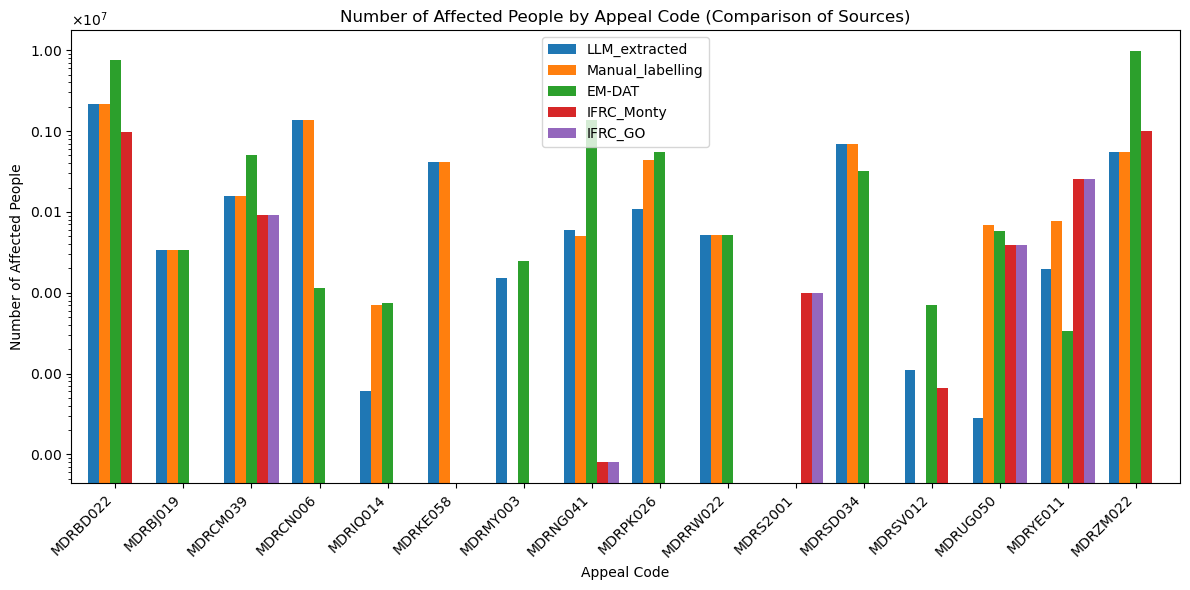

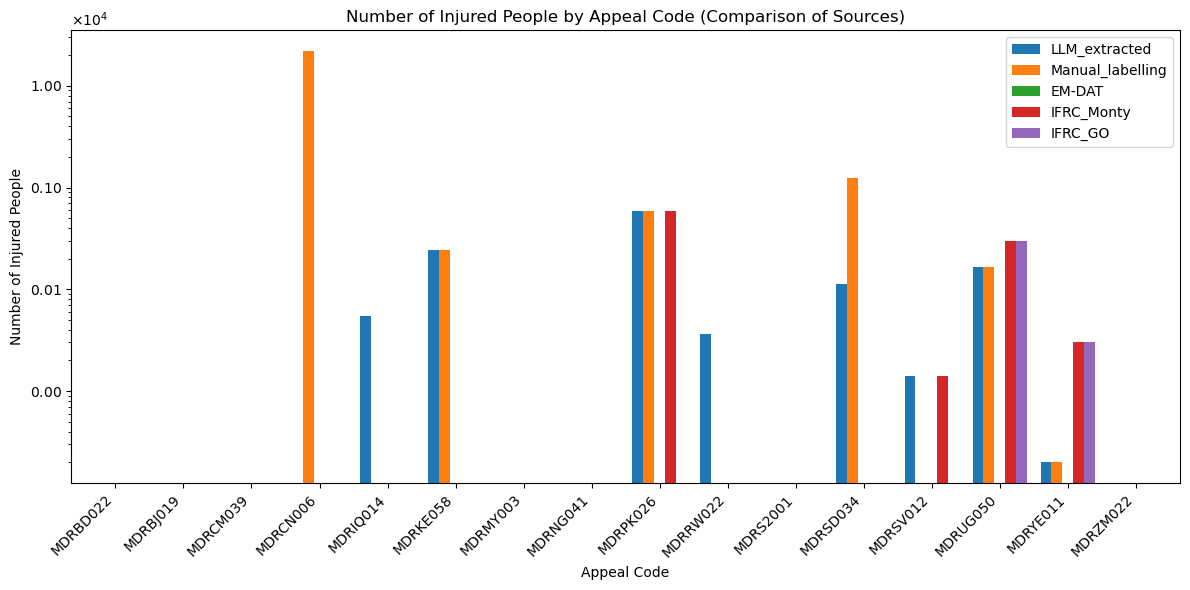

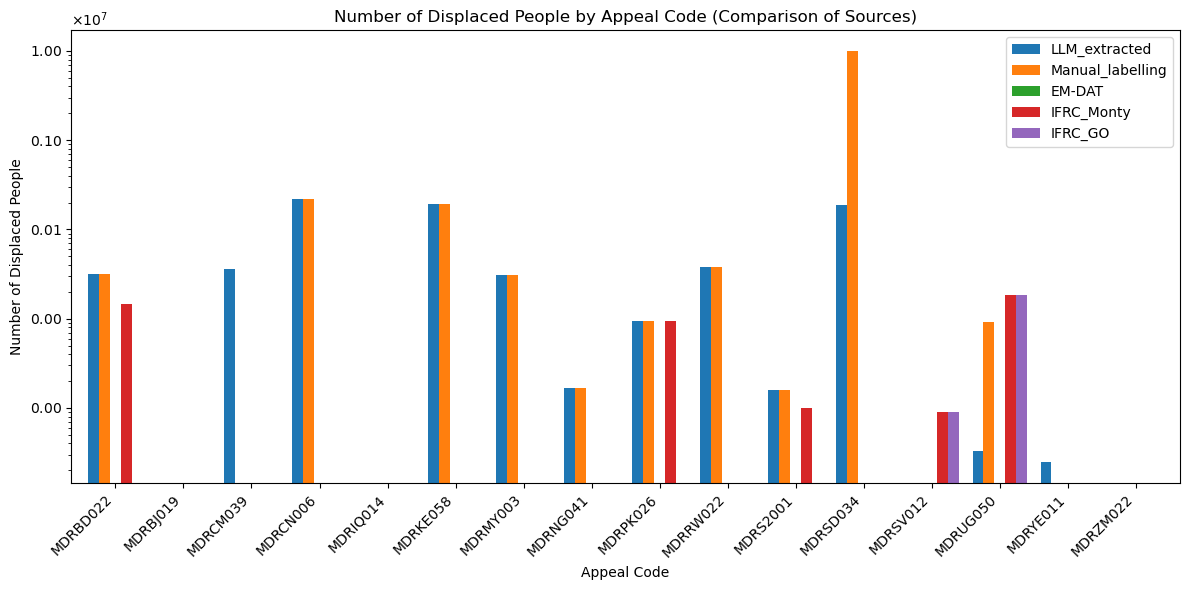

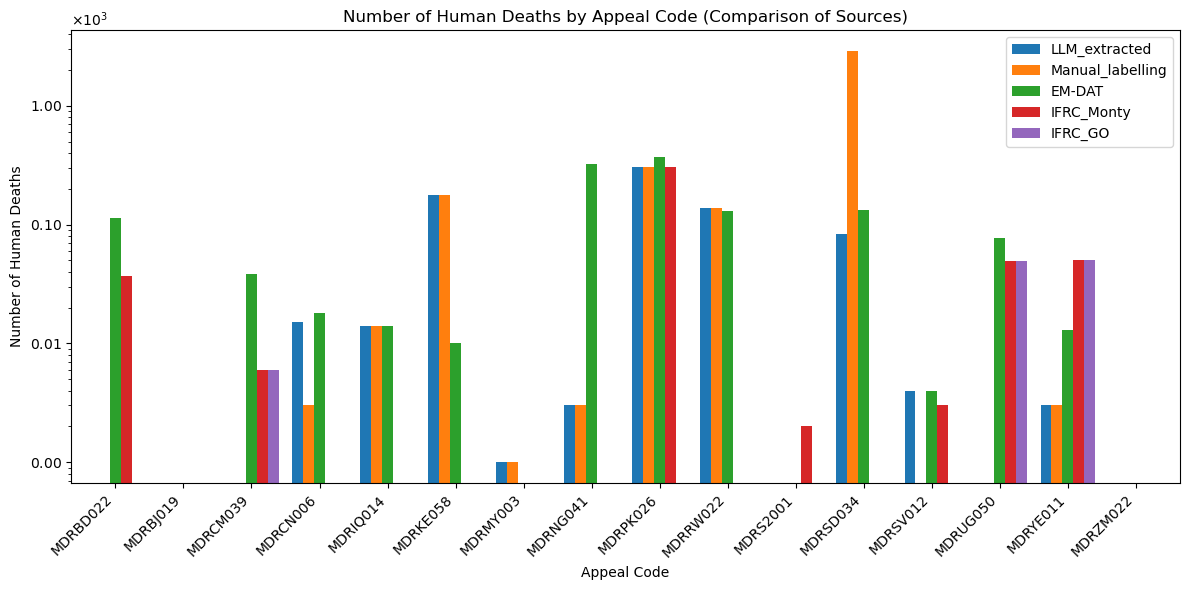

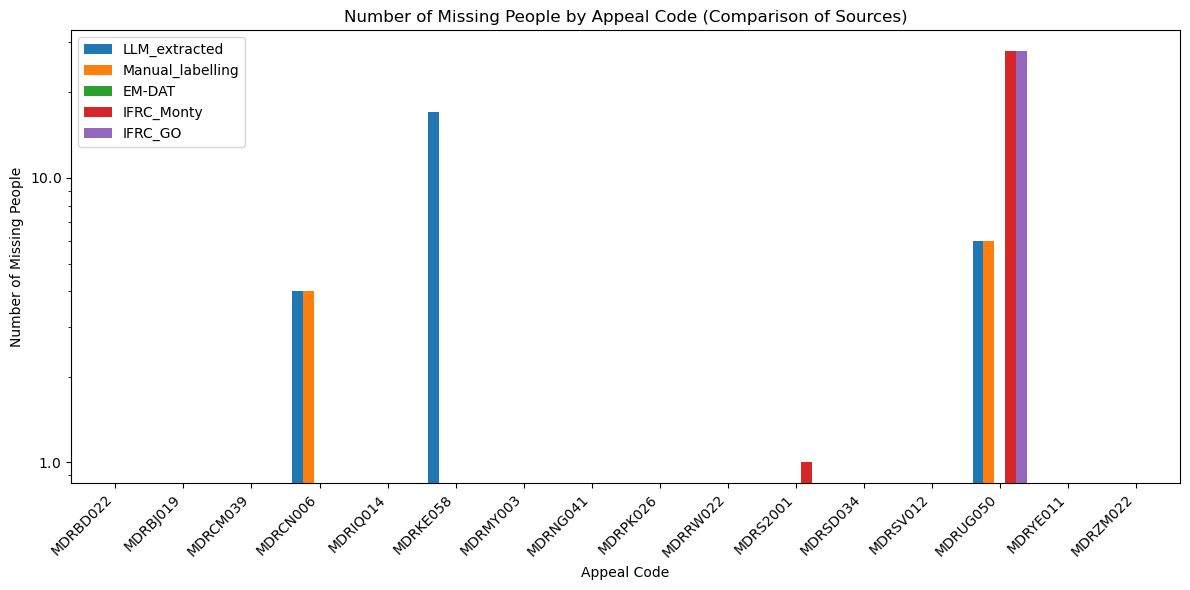

In [59]:
for impactType in list(mapping_impact_type.keys()) : 
    df_plot_data = plot_em_dat_comparison(df_llm_geo_grp, df_labelled_geo_grp, df_llm_linked, df_impact_ifrc_monty_appeal, df_go_all, df_llm_geo_grp.appealCode.unique(), impactType, mapping_impact_type)

## Bar plot relative error 

In [66]:
from matplotlib.ticker import ScalarFormatter

def plot_em_dat_comparison_relative(df_llm_geo_grp, df_labelled_geo_grp, df_emdat_linked, df_impact_ifrc_monty_appeal, df_go, appealCodelist, impactType, mapping_impact_type):
    linthresh=0.1
    margin=1.15
    
    # --- LLM EXTRACTED (reference baseline) ---
    df1 = (
        df_llm_geo_grp[(df_llm_geo_grp["impactSubtype"] == impactType) & 
                       (df_llm_geo_grp["appealCode"].isin(appealCodelist))]
        [["appealCode", "impactValue_final"]]
        .groupby("appealCode", as_index=False)
        .sum()
        .rename(columns={"impactValue_final": "LLM_extracted"})
    )

    # --- MANUALLY LABELLED ---
    df2 = (
        df_labelled_geo_grp[(df_labelled_geo_grp["impactSubtype"] == impactType) & 
                            (df_labelled_geo_grp["appealCode"].isin(appealCodelist))]
        [["appealCode", "impactValue_final"]]
        .groupby("appealCode", as_index=False)
        .sum()
        .rename(columns={"impactValue_final": "Manual_labelling"})
    )

    # --- EMDAT MATCHING ---
    emdat_col = mapping_impact_type[impactType]["emdat"]
    if emdat_col is not None:
        df3 = (
            df_emdat_linked.loc[df_emdat_linked["appealCode"].isin(appealCodelist), ["appealCode", emdat_col]]
            .rename(columns={emdat_col: "EM-DAT"})
            .drop_duplicates()
        )
    else:
        df3 = pd.DataFrame({"appealCode": appealCodelist, "EM-DAT": [np.nan]*len(appealCodelist)})

    # --- IFRC MONTY ---
    df4 = (
        df_impact_ifrc_monty_appeal[(df_impact_ifrc_monty_appeal["impact_type"] == mapping_impact_type[impactType]["monty_ifrc"])& 
                                    (df_impact_ifrc_monty_appeal["appealCode"].isin(appealCodelist))]
        [["appealCode", "impact_value"]]
        .groupby("appealCode", as_index=False)
        .sum()
        .rename(columns={"impact_value": "IFRC_Monty"})
    )

    # --- IFRC GO ---
    df5 = df_go[["appealCode", mapping_impact_type[impactType]["go_ifrc"]]].loc[df_go["appealCode"].isin(appealCodelist)].rename(
        columns={mapping_impact_type[impactType]["go_ifrc"] : "IFRC_GO"}
    )

    # --- Merge all together ---
    df_all = df1.merge(df2, on="appealCode", how="outer") \
                .merge(df3, on="appealCode", how="outer") \
                .merge(df4, on="appealCode", how="outer") \
                .merge(df5, on="appealCode", how="outer")

    # --- Compute relative error with respect to LLM_extracted ---
    ref = df_all["LLM_extracted"]
    df_rel = df_all.set_index("appealCode").drop(columns=["LLM_extracted"])
    df_rel = (df_rel.sub(ref.values, axis=0)).div(ref.values, axis=0)

    # --- Plot ---
    ax = df_rel.plot(
        kind="bar", figsize=(12, 6), width=0.8
    )
    
    # --- Symlog y-scale (works for ± values) ---
    ax.set_yscale("symlog", linthresh=linthresh)  # linear near 0, log beyond

    # --- Center around 0 with symmetric limits ---
    max_abs = np.nanmax(np.abs(df_rel.values))
    if not np.isfinite(max_abs) or max_abs == 0:
        max_abs = 1.0
    ymax = max(linthresh, max_abs) * margin
    ax.set_ylim(-ymax, ymax)

    # --- Horizontal lines at each power of 10 (±) within current limits ---
    # compute exponents covered by current limits, but not below linthresh
    lim = ax.get_ylim()
    max_abs_lim = max(abs(lim[0]), abs(lim[1]))
    k_max = int(np.floor(np.log10(max_abs_lim)))
    k_min = int(np.ceil(np.log10(linthresh)))  # start at boundary of log region
    if k_max >= k_min:
        for k in range(k_min, k_max + 1):
            val = 10.0 ** k
            ax.axhline(val,  color="gray", linestyle="--", linewidth=0.8, alpha=0.7, zorder=0)
            ax.axhline(-val, color="gray", linestyle="--", linewidth=0.8, alpha=0.7, zorder=0)

    # Zero line
    ax.axhline(0, color="black", linewidth=1, zorder=1)

    plt.axhline(0, color="black", linewidth=1)
    plt.title(f"Relative Error vs LLM-extracted for {impactType}")
    plt.xlabel("Appeal Code")
    plt.ylabel("Relative Error (vs LLM-extracted)")
    
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    return df_rel.reset_index()


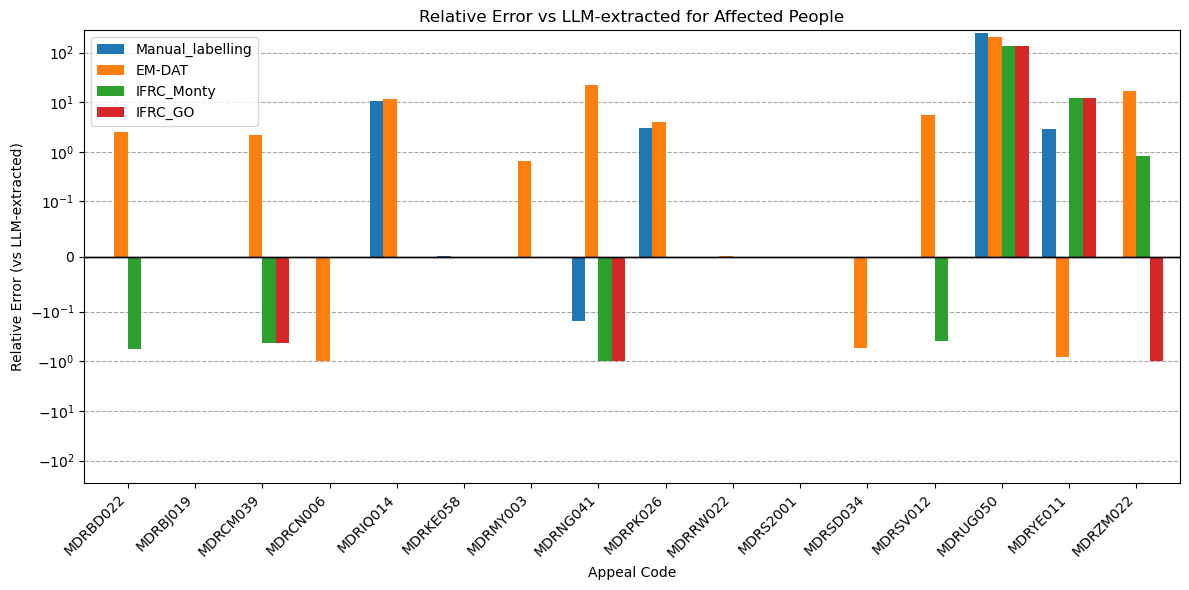

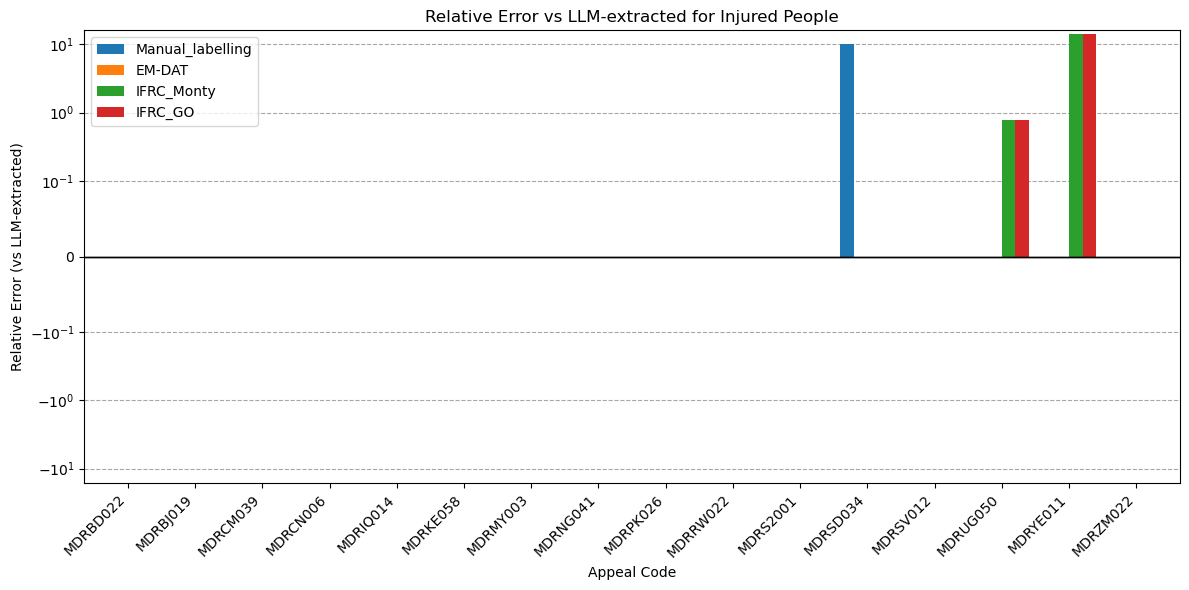

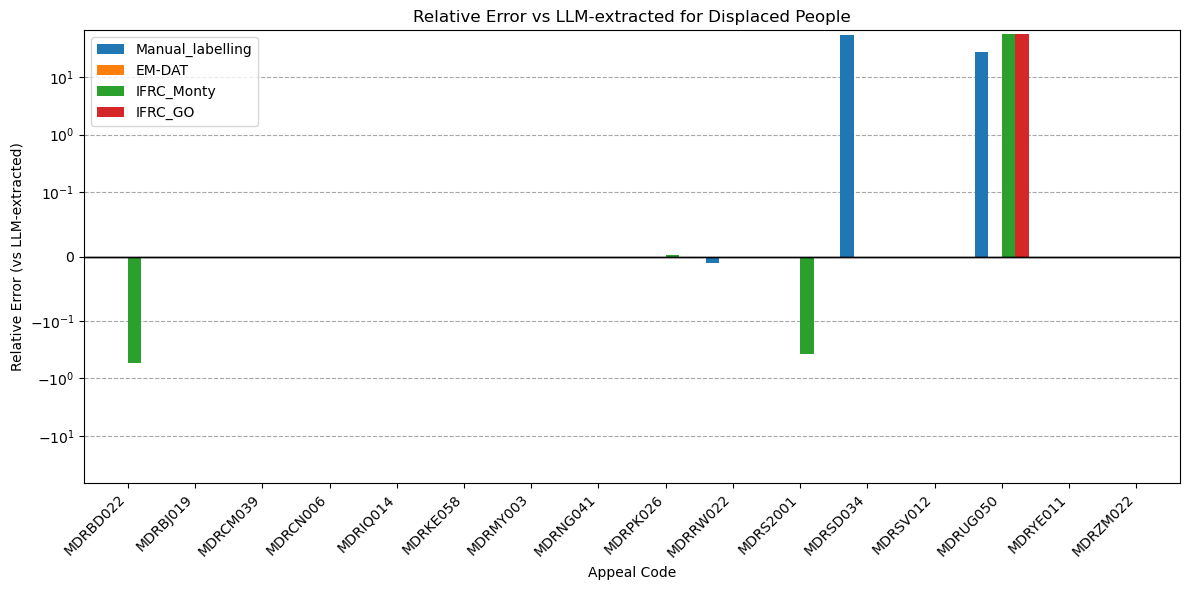

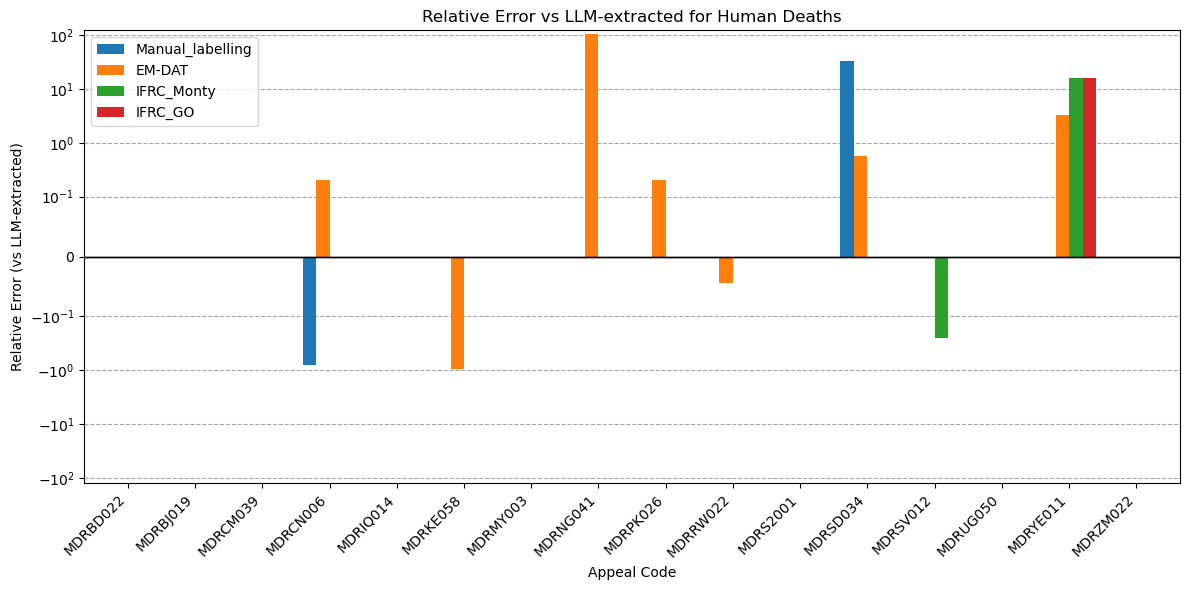

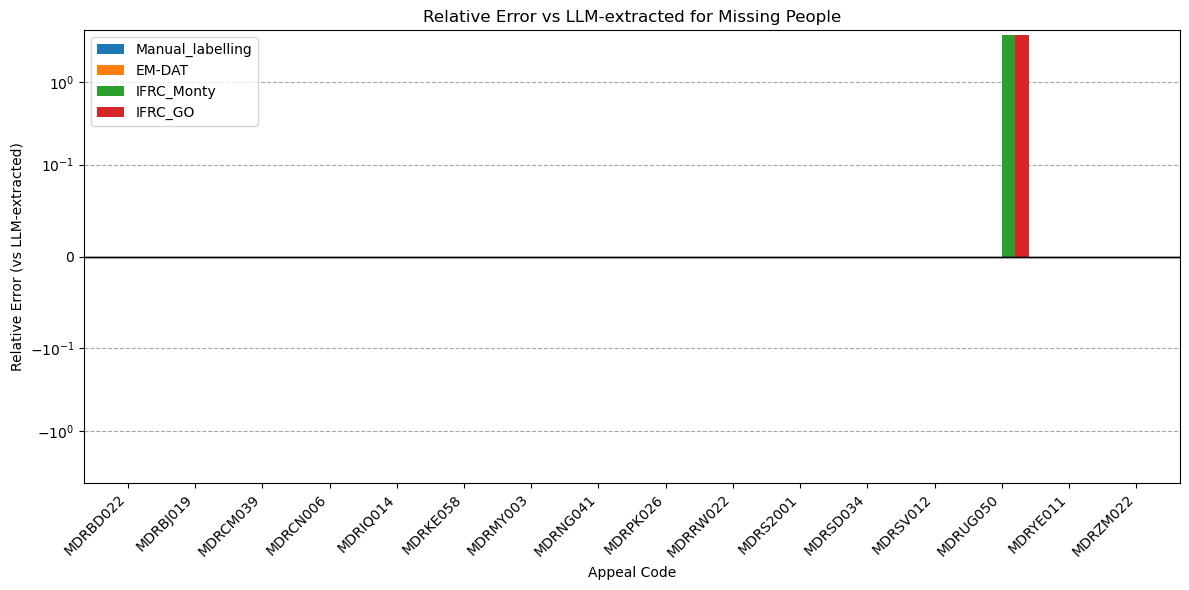

In [68]:
for impactType in list(mapping_impact_type.keys()) : 
    df_plot_data = plot_em_dat_comparison_relative(df_llm_geo_grp, df_labelled_geo_grp, df_llm_linked, df_impact_ifrc_monty_appeal, df_go_all, df_llm_geo_grp.appealCode.unique(), impactType, mapping_impact_type)